In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

import os

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("apartments_pl_2023_08.csv")
df = df[df['city'] =='warszawa']
df.drop(columns=['id', 'city'], inplace=True)
df.reset_index(drop=True, inplace=True)

df.head()

,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,schoolDistance,clinicDistance,postOfficeDistance,kindergartenDistance,restaurantDistance,collegeDistance,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,apartmentBuilding,112.80,4.0,2.0,5.0,1998.0,52.236141,20.987732,1.19,73.0,0.094,0.445,0.466,0.344,0.070,0.784,0.178,cooperative,brick,premium,yes,yes,yes,no,no,2050000
1,blockOfFlats,54.64,2.0,4.0,5.0,1999.0,52.185400,20.959800,5.95,10.0,0.215,1.931,0.940,0.932,0.067,3.064,1.016,condominium,brick,NaN,no,no,yes,no,no,869000
2,blockOfFlats,60.00,3.0,NaN,5.0,2007.0,52.260800,21.058970,4.97,16.0,0.205,0.285,0.769,0.219,0.787,0.366,0.254,condominium,NaN,premium,no,yes,yes,no,no,700000
3,blockOfFlats,28.80,2.0,9.0,11.0,1978.0,52.238200,20.908600,6.51,19.0,0.324,0.301,0.372,0.275,0.211,2.321,0.201,condominium,concreteSlab,NaN,yes,yes,yes,no,yes,435000
4,apartmentBuilding,122.70,5.0,3.0,3.0,1998.0,52.168100,21.079000,8.74,12.0,0.449,1.721,0.311,0.195,0.484,2.651,0.197,condominium,brick,NaN,yes,yes,no,yes,no,1500000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5471 entries, 0 to 5470
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  4142 non-null   object 
 1   squareMeters          5471 non-null   float64
 2   rooms                 5471 non-null   float64
 3   floor                 4614 non-null   float64
 4   floorCount            5422 non-null   float64
 5   buildYear             4936 non-null   float64
 6   latitude              5471 non-null   float64
 7   longitude             5471 non-null   float64
 8   centreDistance        5471 non-null   float64
 9   poiCount              5471 non-null   float64
 10  schoolDistance        5470 non-null   float64
 11  clinicDistance        5426 non-null   float64
 12  postOfficeDistance    5465 non-null   float64
 13  kindergartenDistance  5470 non-null   float64
 14  restaurantDistance    5444 non-null   float64
 15  collegeDistance      

In [5]:
df.describe()

,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,schoolDistance,clinicDistance,postOfficeDistance,kindergartenDistance,restaurantDistance,collegeDistance,pharmacyDistance,price
count,5471.000000,5471.000000,4614.000000,5422.000000,4936.000000,5471.000000,5471.000000,5471.000000,5471.000000,5470.000000,5426.000000,5465.000000,5470.000000,5444.000000,5290.000000,5464.000000,5.471000e+03
mean,60.859927,2.724182,3.775466,6.204168,1989.051256,52.229093,21.010039,6.172312,22.128678,0.355062,0.870032,0.489440,0.274257,0.252720,1.581345,0.310966,9.198403e+05
std,22.798343,0.933902,3.038569,3.880881,28.685310,0.048520,0.065199,3.316952,21.816575,0.269981,0.887048,0.355523,0.207467,0.236253,1.174941,0.282324,4.074346e+05
min,25.000000,1.000000,1.000000,1.000000,1851.000000,52.116780,20.823898,0.020000,0.000000,0.004000,0.005000,0.001000,0.004000,0.001000,0.013000,0.003000,3.276350e+05
25%,45.015000,2.000000,2.000000,4.000000,1970.000000,52.195123,20.963651,3.710000,9.000000,0.176250,0.293000,0.245000,0.142000,0.098000,0.640000,0.137000,6.300000e+05
50%,56.600000,3.000000,3.000000,5.000000,1998.000000,52.229676,21.010280,6.050000,16.000000,0.282000,0.536500,0.407000,0.230000,0.187000,1.226000,0.233000,7.990000e+05
75%,72.315000,3.000000,5.000000,8.000000,2013.000000,52.256762,21.051640,8.290000,27.000000,0.447000,1.044750,0.635000,0.351000,0.335000,2.290000,0.394000,1.100000e+06
max,150.000000,6.000000,29.000000,29.000000,2023.000000,52.362550,21.249710,16.940000,130.000000,2.346000,4.989000,3.524000,2.271000,2.050000,4.998000,3.036000,2.500000e+06


In [6]:
df.isna().sum()

type                    1329
squareMeters               0
rooms                      0
floor                    857
floorCount                49
buildYear                535
latitude                   0
longitude                  0
centreDistance             0
poiCount                   0
schoolDistance             1
clinicDistance            45
postOfficeDistance         6
kindergartenDistance       1
restaurantDistance        27
collegeDistance          181
pharmacyDistance           7
ownership                  0
buildingMaterial        2217
condition               4240
hasParkingSpace            0
hasBalcony                 0
hasElevator              207
hasSecurity                0
hasStorageRoom             0
price                      0
dtype: int64

In [7]:
print(df['type'].unique())
print(df['condition'].unique())
print(df['ownership'].unique())
print(df['buildingMaterial'].unique())

['apartmentBuilding' 'blockOfFlats' nan 'tenement']
['premium' nan 'low']
['cooperative' 'condominium']
['brick' nan 'concreteSlab']


In [8]:
categorical_columns = [x for x in df.columns if df[x].dtype == 'object']

for x in categorical_columns:
    print(x)
    print(df[x].unique())

type
['apartmentBuilding' 'blockOfFlats' nan 'tenement']
ownership
['cooperative' 'condominium']
buildingMaterial
['brick' nan 'concreteSlab']
condition
['premium' nan 'low']
hasParkingSpace
['yes' 'no']
hasBalcony
['yes' 'no']
hasElevator
['yes' 'no' nan]
hasSecurity
['no' 'yes']
hasStorageRoom
['no' 'yes']


In [9]:
le = LabelEncoder()

for x in categorical_columns:
    df[x] = le.fit_transform(df[x])
    #df.drop(columns=[x], inplace=True)

df.head()

,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,schoolDistance,clinicDistance,postOfficeDistance,kindergartenDistance,restaurantDistance,collegeDistance,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,0,112.80,4.0,2.0,5.0,1998.0,52.236141,20.987732,1.19,73.0,0.094,0.445,0.466,0.344,0.070,0.784,0.178,1,0,1,1,1,1,0,0,2050000
1,1,54.64,2.0,4.0,5.0,1999.0,52.185400,20.959800,5.95,10.0,0.215,1.931,0.940,0.932,0.067,3.064,1.016,0,0,2,0,0,1,0,0,869000
2,1,60.00,3.0,NaN,5.0,2007.0,52.260800,21.058970,4.97,16.0,0.205,0.285,0.769,0.219,0.787,0.366,0.254,0,2,1,0,1,1,0,0,700000
3,1,28.80,2.0,9.0,11.0,1978.0,52.238200,20.908600,6.51,19.0,0.324,0.301,0.372,0.275,0.211,2.321,0.201,0,1,2,1,1,1,0,1,435000
4,0,122.70,5.0,3.0,3.0,1998.0,52.168100,21.079000,8.74,12.0,0.449,1.721,0.311,0.195,0.484,2.651,0.197,0,0,2,1,1,0,1,0,1500000


In [ ]:
# Oblicz korelacje z kolumną price
correlations_with_price = df.corr()['price'].abs().sort_values(ascending=False)

# Wyświetl korelacje (opcjonalnie)
print(correlations_with_price)

# Ustal próg (np. 0.1 – możesz zmienić)
threshold = 0.1

# Znajdź kolumny do usunięcia (bez 'price' i bez kolumn, które są zbyt słabo skorelowane)
columns_to_drop = correlations_with_price[correlations_with_price < threshold].index

# Usuń kolumny (ale nie 'price')
columns_to_drop = [col for col in columns_to_drop if col != 'price']

# Usuń kolumny
df_cleaned = df.drop(columns=columns_to_drop)

# Sprawdź, co zostało
print(f"Usunięto {len(columns_to_drop)} kolumn.")
print(f"Zostało {df_cleaned.shape[1]} kolumn.")

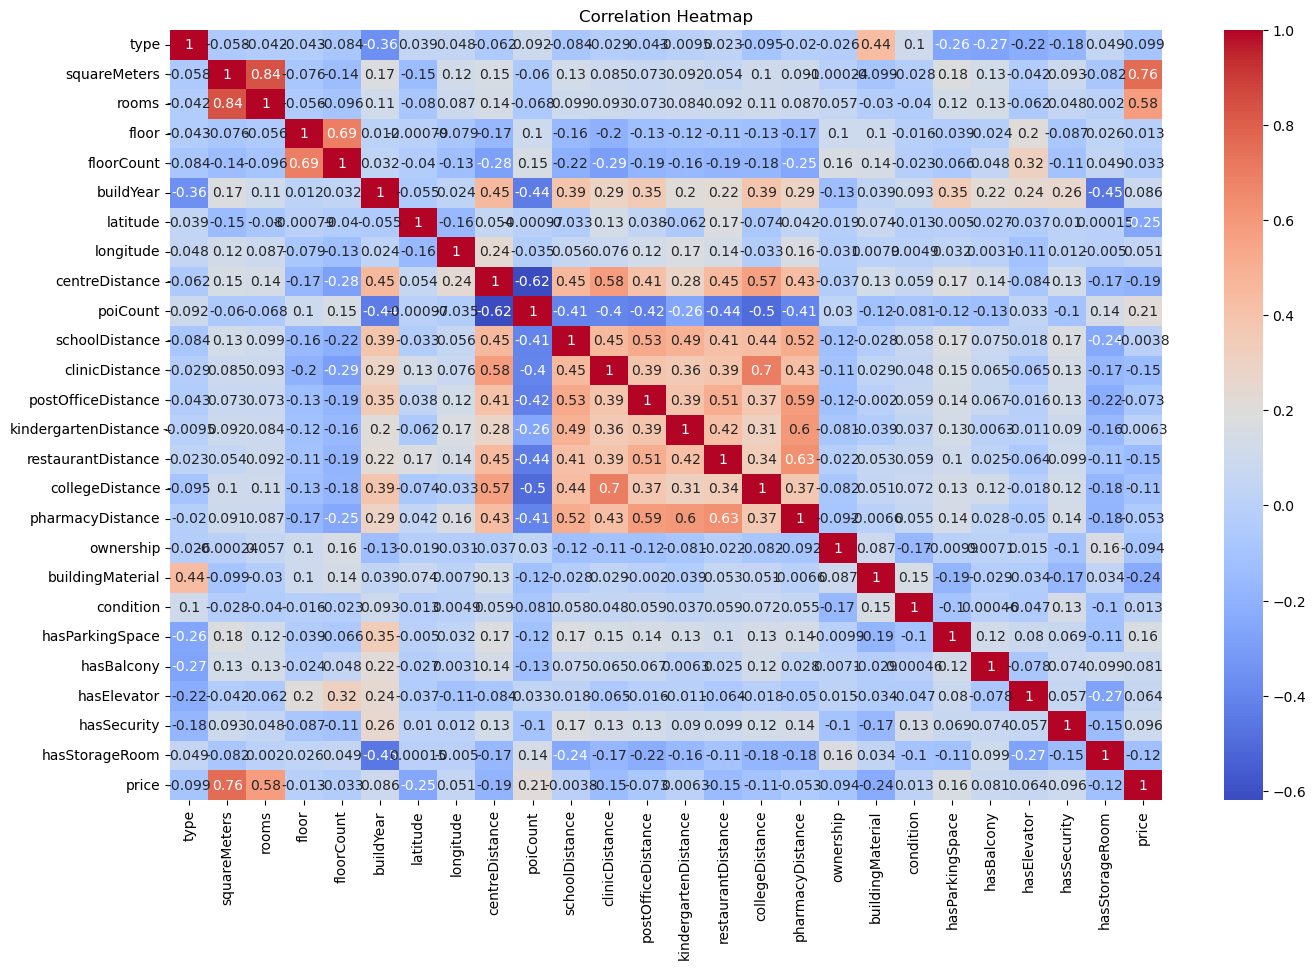

In [10]:
plt.figure(figsize=(16,10))
cor_matrix= df.corr()
sns.heatmap(cor_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
#have to delete columns with so many null values and columns that do not affect price
columns_to_delete = ['floor','floorCount','schoolDistance','clinicDistance','postOfficeDistance','kindergartenDistance','collegeDistance', 'pharmacyDistance','buildYear','','','','']

## EDA